# Hotdog / Not Hotdog — Baseline CNN

This notebook trains a simple baseline CNN on the hotdog/not-hotdog dataset. Everything is driven by a single
`config` dictionary and a `run_experiment(config)` function, so the hyperparameter search in the next stage can
reuse the exact same code.

**Workflow**
1. Mount Google Drive and copy the dataset to the local Colab disk (much faster than reading from Drive).
2. Split the official `train` folder into **train / validation**. All model selection happens on validation;
   the `test` folder is only touched for the final evaluation.
3. Train a baseline CNN (no batch norm, no augmentation, no dropout, Adam, lr=1e-3).
4. Evaluate on test and inspect misclassified images.

> Runtime → Change runtime type → **GPU** before running.

## 1. Setup

In [ ]:
import os, glob, json, random, shutil, time, copy
import numpy as np
import PIL.Image as Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

Device: cuda | Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# >>> Change this to where the 'hotdog_nothotdog' folder lives in your Drive <<<
DRIVE_DATA_PATH = '/content/drive/MyDrive/hotdog_nothotdog'
LOCAL_DATA_PATH = '/content/hotdog_nothotdog'
RESULTS_DIR     = '/content/drive/MyDrive/hotdog_results'   # results survive Colab disconnects
os.makedirs(RESULTS_DIR, exist_ok=True)

# Reading thousands of small files from Drive is slow, so copy once to the local disk.
if not os.path.exists(LOCAL_DATA_PATH):
    print('Copying dataset to local disk...')
    shutil.copytree(DRIVE_DATA_PATH, LOCAL_DATA_PATH)
DATA_PATH = LOCAL_DATA_PATH

for split in ['train', 'test']:
    for c in ['hotdog', 'nothotdog']:
        n = len(glob.glob(os.path.join(DATA_PATH, split, c, '*.jpg')))
        print(f'{split:5s}/{c:9s}: {n} images')

Mounted at /content/drive
Copying dataset to local disk...
train/hotdog   : 1075 images
train/nothotdog: 972 images
test /hotdog   : 895 images
test /nothotdog: 967 images


In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Dataset

Same idea as the provided class, with two small changes:
- `.convert('RGB')`: some ImageNet JPEGs are grayscale or CMYK, which would crash batching.
- The image paths are sorted, so indices are reproducible (needed for the train/val split and for
  looking up misclassified images later).

Labels: `hotdog = 0`, `nothotdog = 1`.

In [ ]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path=DATA_PATH):
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = sorted(os.path.split(d)[1] for d in glob.glob(data_path + '/*') if os.path.isdir(d))
        self.name_to_label = {c: i for i, c in enumerate(image_classes)}
        self.image_paths = sorted(glob.glob(data_path + '/*/*.jpg'))
        self.labels = [self.name_to_label[os.path.basename(os.path.dirname(p))] for p in self.image_paths]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(image), self.labels[idx]

CLASS_NAMES = ['hotdog', 'nothotdog']
print(Hotdog_NotHotdog(train=True, transform=None).name_to_label)

{'hotdog': 0, 'nothotdog': 1}


## 3. Transforms

Images are squished to a square (as in the starter code) and normalised with ImageNet statistics
(this also makes the pipeline directly compatible with pretrained models if you try transfer learning later).

Three augmentation levels are defined already so they can be searched over later. **The baseline uses `'none'`.**
Validation and test images are never augmented.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size=128, augmentation='none'):
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    eval_tf = transforms.Compose([transforms.Resize((img_size, img_size)),
                                  transforms.ToTensor(), normalize])
    if augmentation == 'none':
        train_tf = eval_tf
    elif augmentation == 'basic':
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(), normalize])
    elif augmentation == 'strong':
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(0.3, 0.3, 0.3, 0.05),
            transforms.ToTensor(), normalize])
    else:
        raise ValueError(augmentation)
    return train_tf, eval_tf

## 4. Train / validation split

A stratified 80/20 split of the official training folder, with a fixed seed, so every experiment in the
hyperparameter search sees exactly the same split. Two dataset objects share the same files but use different
transforms (augmented for train, plain for validation).

In [ ]:
VAL_FRACTION = 0.2
_full = Hotdog_NotHotdog(train=True, transform=None)
train_idx, val_idx = train_test_split(np.arange(len(_full)), test_size=VAL_FRACTION,
                                      stratify=_full.labels, random_state=42)
print(f'train: {len(train_idx)}  val: {len(val_idx)}')

def get_loaders(config):
    train_tf, eval_tf = get_transforms(config['img_size'], config['augmentation'])
    train_set = Subset(Hotdog_NotHotdog(train=True,  transform=train_tf), train_idx)
    val_set   = Subset(Hotdog_NotHotdog(train=True,  transform=eval_tf),  val_idx)
    test_set  = Hotdog_NotHotdog(train=False, transform=eval_tf)
    kw = dict(batch_size=config['batch_size'], num_workers=2, pin_memory=True)
    return (DataLoader(train_set, shuffle=True, drop_last=True, **kw),
            DataLoader(val_set,   shuffle=False, **kw),
            DataLoader(test_set,  shuffle=False, **kw))

train: 1637  val: 410


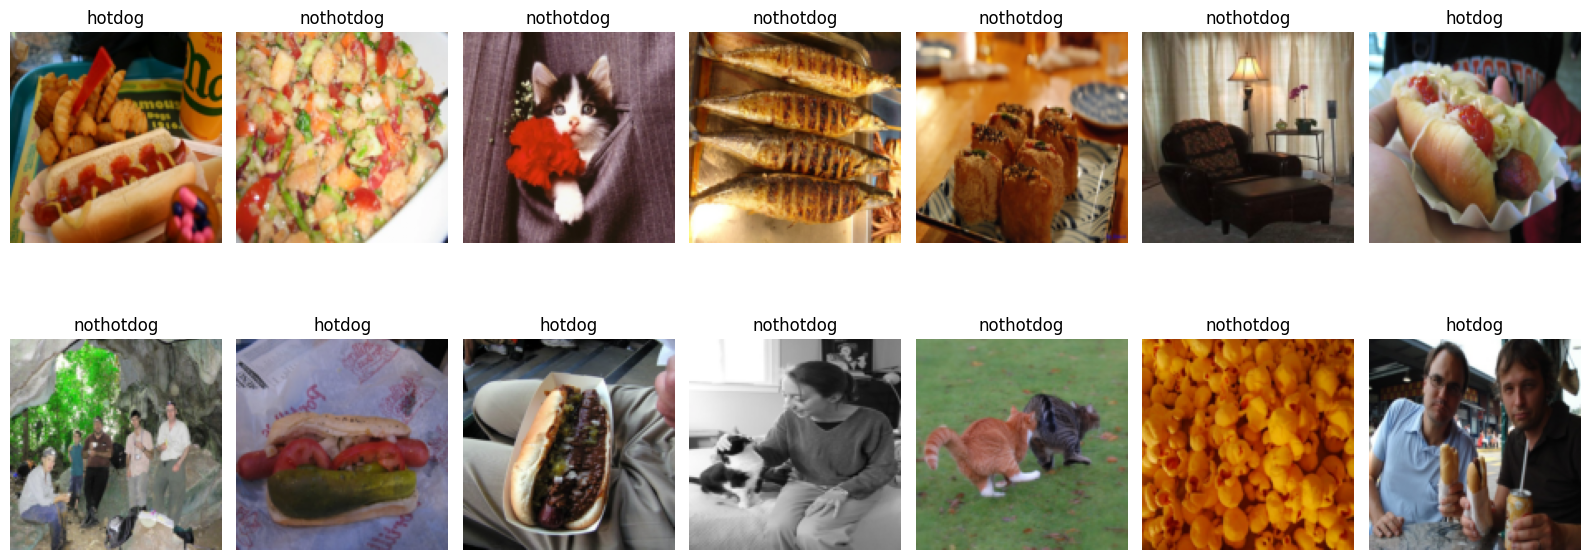

In [ ]:
# Quick look at a few training images (undo the normalisation for display)
def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

_tl, _, _ = get_loaders({'img_size': 128, 'augmentation': 'none', 'batch_size': 32})
images, labels = next(iter(_tl))
plt.figure(figsize=(16, 7))
for i in range(14):
    plt.subplot(2, 7, i + 1); plt.imshow(denorm(images[i]))
    plt.title(CLASS_NAMES[labels[i]]); plt.axis('off')
plt.tight_layout(); plt.show()

## 5. Model

A plain VGG-style CNN: `n` blocks of `[Conv3x3 → (BatchNorm) → ReLU] × convs_per_block → MaxPool2d`,
followed by global average pooling, (dropout) and a linear layer with 2 outputs.

Global average pooling keeps the parameter count small and makes the network independent of the input
resolution, so `img_size` can be changed in the search without touching the architecture.
The options for batch norm, dropout, width and depth are all exposed so they can be searched over later.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), convs_per_block=1,
                 use_batchnorm=False, dropout=0.0, num_classes=2):
        super().__init__()
        layers, in_ch = [], 3
        for out_ch in channels:
            for _ in range(convs_per_block):
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not use_batchnorm))
                if use_batchnorm:
                    layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.ReLU(inplace=True))
                in_ch = out_ch
            layers.append(nn.MaxPool2d(2))
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(in_ch, num_classes))

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


def build_model(config):
    return SimpleCNN(channels=config['channels'], convs_per_block=config['convs_per_block'],
                     use_batchnorm=config['use_batchnorm'], dropout=config['dropout'])


def build_optimizer(model, config):
    lr, wd = config['lr'], config['weight_decay']
    if config['optimizer'] == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    if config['optimizer'] == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if config['optimizer'] == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    raise ValueError(config['optimizer'])


def build_scheduler(optimizer, config):
    if config['scheduler'] == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])
    return None


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Training and evaluation

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        if criterion is not None:
            total_loss += criterion(out, y).item() * x.size(0)
        all_probs.append(F.softmax(out, 1).cpu())
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
    preds, labels = torch.cat(all_preds), torch.cat(all_labels)
    return {'loss': total_loss / len(labels), 'acc': (preds == labels).float().mean().item(),
            'preds': preds, 'labels': labels, 'probs': torch.cat(all_probs)}


def run_experiment(config, verbose=True):
    """Train one model with `config`. Keeps the weights with the best *validation* accuracy."""
    set_seed(config.get('seed', 42))
    train_loader, val_loader, _ = get_loaders(config)
    model = build_model(config).to(device)
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config)
    criterion = nn.CrossEntropyLoss()

    history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
    best_acc, best_state, best_epoch = 0.0, None, 0
    t0 = time.time()
    for epoch in tqdm(range(config['epochs']), desc=config.get('name', 'run'), disable=not verbose):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val = evaluate(model, val_loader, criterion)
        if scheduler: scheduler.step()
        for k, v in zip(history, [tr_loss, tr_acc, val['loss'], val['acc']]):
            history[k].append(v)
        if val['acc'] > best_acc:
            best_acc, best_epoch = val['acc'], epoch + 1
            best_state = copy.deepcopy(model.state_dict())
        if verbose:
            print(f'Epoch {epoch+1:3d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | '
                  f'val loss {val["loss"]:.3f} acc {val["acc"]:.3f}')

    model.load_state_dict(best_state)
    summary = {'config': config, 'best_val_acc': best_acc, 'best_epoch': best_epoch,
               'params': count_params(model), 'train_time_s': time.time() - t0, 'history': history}
    return model, summary


def plot_history(history, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax[0].plot(ep, history['train_loss'], label='train'); ax[0].plot(ep, history['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(ep, history['train_acc'], label='train'); ax[1].plot(ep, history['val_acc'], label='val')
    ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()


def save_summary(summary):
    path = os.path.join(RESULTS_DIR, f"{summary['config']['name']}.json")
    with open(path, 'w') as f:
        json.dump(summary, f, indent=2)
    print('Saved', path)

## 7. Baseline

Deliberately plain: no batch norm, no dropout, no augmentation, no weight decay, no LR schedule, Adam with lr=1e-3.
Every later experiment is compared against this number.

Parameters: 388930


baseline:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch   1 | train loss 0.651 acc 0.623 | val loss 0.666 acc 0.651
Epoch   2 | train loss 0.617 acc 0.690 | val loss 0.638 acc 0.656
Epoch   3 | train loss 0.598 acc 0.711 | val loss 0.616 acc 0.666
Epoch   4 | train loss 0.574 acc 0.722 | val loss 0.617 acc 0.663
Epoch   5 | train loss 0.535 acc 0.744 | val loss 0.635 acc 0.629
Epoch   6 | train loss 0.540 acc 0.734 | val loss 0.552 acc 0.705
Epoch   7 | train loss 0.478 acc 0.778 | val loss 0.589 acc 0.707
Epoch   8 | train loss 0.484 acc 0.768 | val loss 0.530 acc 0.710
Epoch   9 | train loss 0.457 acc 0.792 | val loss 0.527 acc 0.727
Epoch  10 | train loss 0.502 acc 0.771 | val loss 0.554 acc 0.710
Epoch  11 | train loss 0.442 acc 0.802 | val loss 0.513 acc 0.734
Epoch  12 | train loss 0.429 acc 0.806 | val loss 0.589 acc 0.707
Epoch  13 | train loss 0.419 acc 0.818 | val loss 0.510 acc 0.746
Epoch  14 | train loss 0.398 acc 0.831 | val loss 0.496 acc 0.746
Epoch  15 | train loss 0.375 acc 0.834 | val loss 0.497 acc 0.773
Epoch  16 

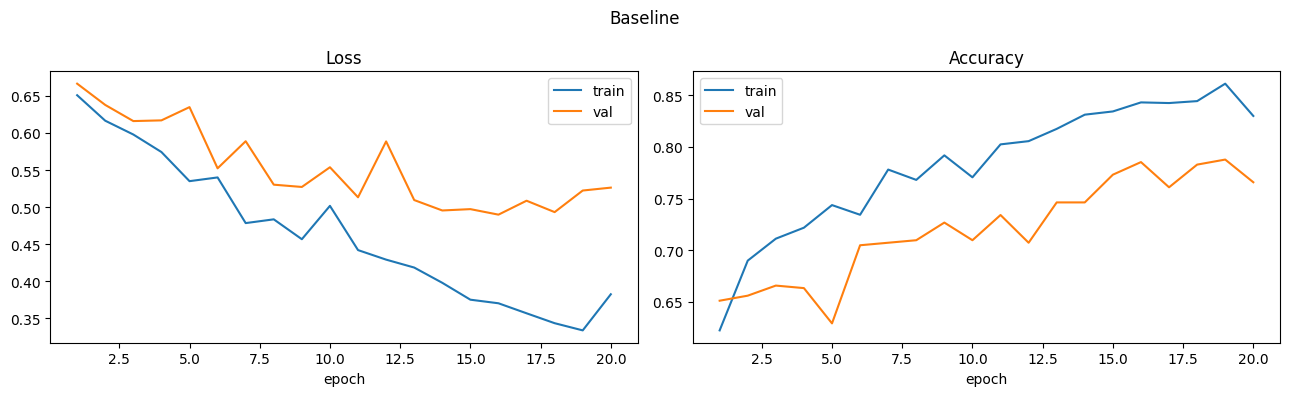

In [ ]:
baseline_config = {
    'name':            'baseline',
    'seed':            42,
    # data
    'img_size':        128,
    'batch_size':      64,
    'augmentation':    'none',     # 'none' | 'basic' | 'strong'
    # model
    'channels':        (32, 64, 128, 256),
    'convs_per_block': 1,
    'use_batchnorm':   False,
    'dropout':         0.0,
    # optimisation
    'optimizer':       'adam',     # 'adam' | 'adamw' | 'sgd'
    'lr':              1e-3,
    'weight_decay':    0.0,
    'scheduler':       'none',     # 'none' | 'cosine'
    'epochs':          20,
}

print('Parameters:', count_params(build_model(baseline_config)))
baseline_model, baseline_summary = run_experiment(baseline_config)
print(f"\nBest val acc: {baseline_summary['best_val_acc']:.4f} at epoch {baseline_summary['best_epoch']}")
plot_history(baseline_summary['history'], 'Baseline')

## 8. Test evaluation

Only done once per *final* model. During the hyperparameter search, compare models on validation accuracy only.

Test accuracy: 0.7825


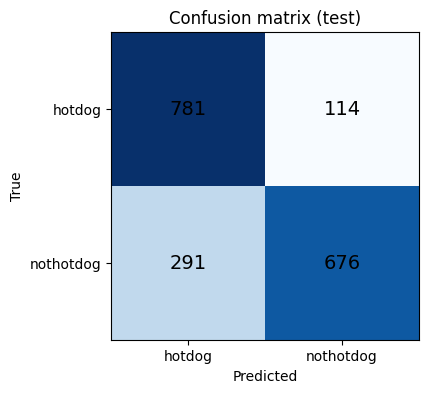

Saved /content/drive/MyDrive/hotdog_results/baseline.json


In [ ]:
_, _, test_loader = get_loaders(baseline_config)
test_res = evaluate(baseline_model, test_loader, nn.CrossEntropyLoss())
baseline_summary['test_acc'] = test_res['acc']
print(f"Test accuracy: {test_res['acc']:.4f}")

cm = confusion_matrix(test_res['labels'], test_res['preds'])
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
plt.xticks([0, 1], CLASS_NAMES); plt.yticks([0, 1], CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix (test)')
plt.show()

save_summary(baseline_summary)

405 misclassified out of 1862


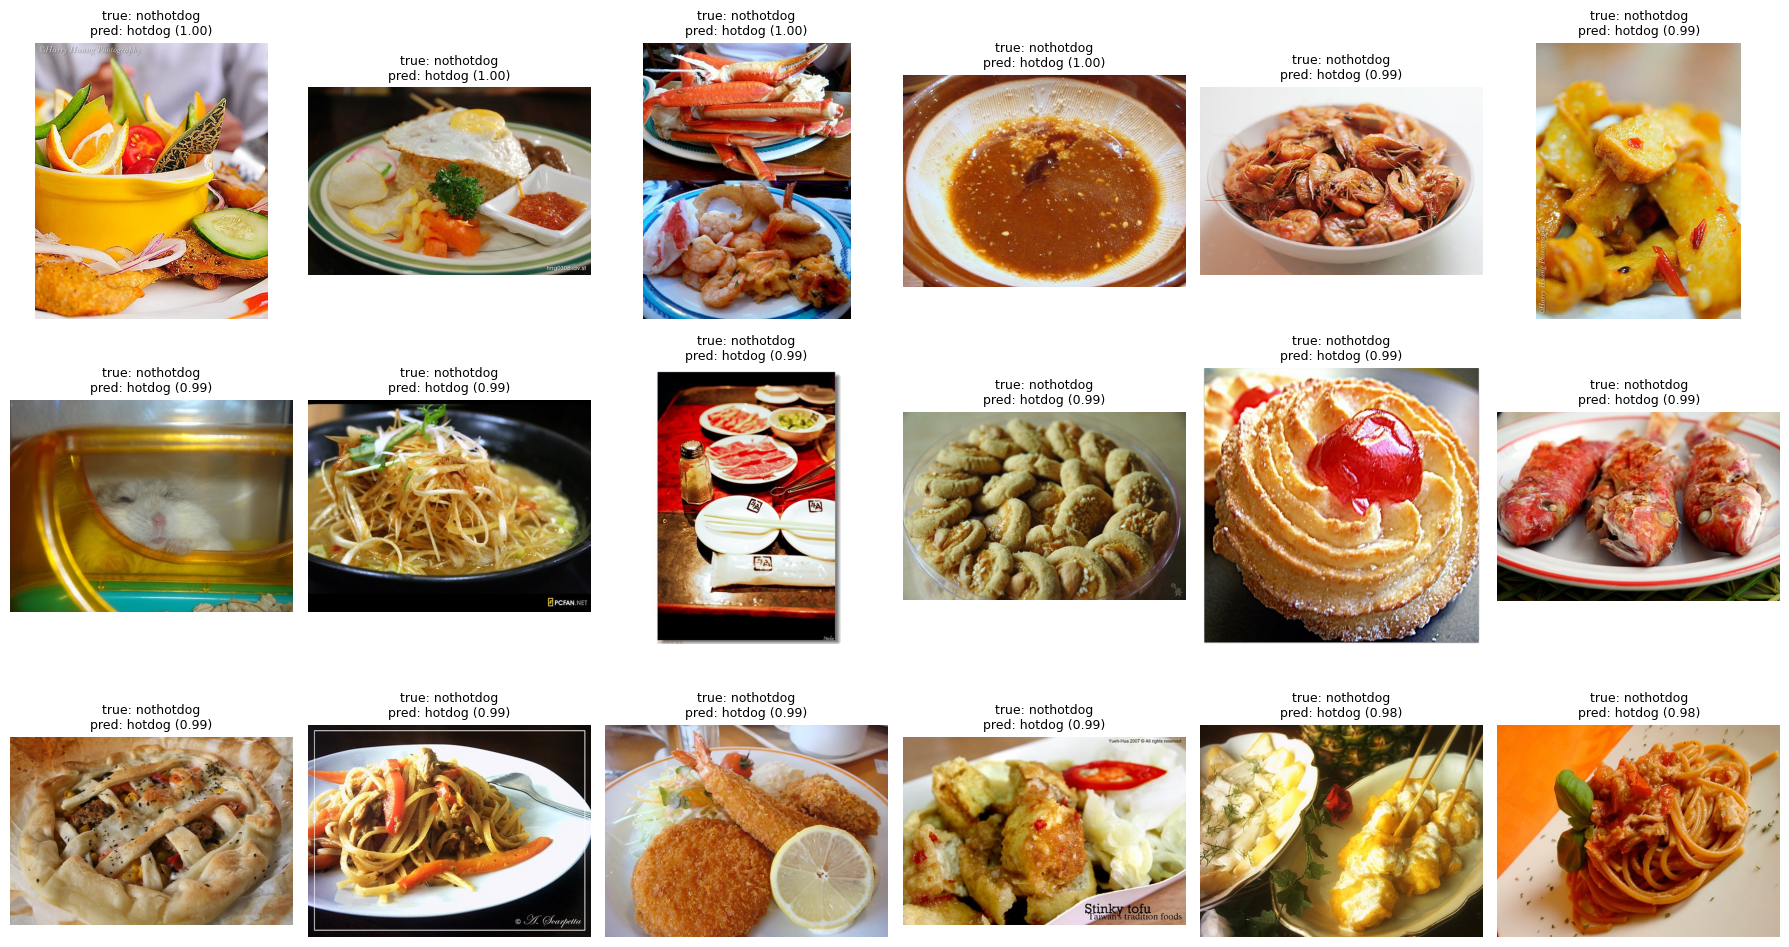

In [ ]:
# Misclassified test images, most confident mistakes first
test_ds = test_loader.dataset
wrong = torch.where(test_res['preds'] != test_res['labels'])[0]
conf = test_res['probs'][wrong].max(1).values
wrong = wrong[conf.argsort(descending=True)]
print(f'{len(wrong)} misclassified out of {len(test_ds)}')

n_show = min(18, len(wrong))
plt.figure(figsize=(18, 3.3 * ((n_show + 5) // 6)))
for k, idx in enumerate(wrong[:n_show].tolist()):
    img = Image.open(test_ds.image_paths[idx]).convert('RGB')
    t, p = test_res['labels'][idx].item(), test_res['preds'][idx].item()
    plt.subplot((n_show + 5) // 6, 6, k + 1); plt.imshow(img); plt.axis('off')
    plt.title(f'true: {CLASS_NAMES[t]}\npred: {CLASS_NAMES[p]} ({test_res["probs"][idx, p]:.2f})', fontsize=9)
plt.tight_layout(); plt.show()

# Hyperparameter search

The baseline was **underfitting** (train acc ≈ 84% and still rising at epoch 20) and its validation curve was noisy.
The search is therefore staged, each stage building on the winner of the previous one:

| Stage | Question | Runs |
|---|---|---|
| 1 | Does training longer help? Does a cosine LR schedule help? | 2 |
| 2 | Which optimizer and learning rate? (Adam vs SGD+momentum, 4 learning rates each) | 8 |
| 3 | Does batch norm help, and does it change the best learning rate? | 10 |

**How runs are compared.** With 410 validation images the standard error of an accuracy around 80% is
√(0.8·0.2/410) ≈ 2%, so the single best epoch is partly luck. Runs are ranked by **`val_acc_last5`**, the mean
validation accuracy over the last 5 epochs. `best_val_acc` is still reported, and the saved weights are those of
the best epoch.

**Resuming.** Every run writes `<name>.json` and `<name>.pt` to `RESULTS_DIR` on Drive. If Colab disconnects, rerun
the setup cells (sections 1–6 and the `baseline_config` cell; the baseline training itself can be skipped) and then
the search cells: finished runs are loaded instead of retrained.

The test set is not used anywhere in the search.

## 10. Search utilities

In [ ]:
import pandas as pd
from IPython.display import display
pd.set_option('display.precision', 4)
pd.set_option('display.width', 200)


def run_or_load(config, force=False):
    """Train `config` unless its results already exist on Drive. Returns the summary dict."""
    json_path = os.path.join(RESULTS_DIR, f"{config['name']}.json")
    if os.path.exists(json_path) and not force:
        with open(json_path) as f:
            s = json.load(f)
        print(f"[loaded] {config['name']:30s} best val {s['best_val_acc']:.4f}")
        return s
    model, s = run_experiment(config, verbose=False)
    h = s['history']
    s['val_acc_last5'] = float(np.mean(h['val_acc'][-5:]))
    with open(json_path, 'w') as f:
        json.dump(s, f, indent=2)
    torch.save(model.state_dict(), os.path.join(RESULTS_DIR, f"{config['name']}.pt"))
    print(f"[done]   {config['name']:30s} best val {s['best_val_acc']:.4f} | last5 {s['val_acc_last5']:.4f} "
          f"| train last5 {np.mean(h['train_acc'][-5:]):.4f} | {s['train_time_s']/60:.1f} min")
    del model
    torch.cuda.empty_cache()
    return s


def load_summary(name):
    with open(os.path.join(RESULTS_DIR, f'{name}.json')) as f:
        return json.load(f)


def load_results(prefixes=None):
    """Table of all saved runs (optionally only names starting with one of `prefixes`), best first."""
    rows = []
    for p in sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json'))):
        with open(p) as f:
            s = json.load(f)
        if 'history' not in s:   # e.g. best_config_*.json
            continue
        c, h = s['config'], s['history']
        if prefixes and not c['name'].startswith(tuple(prefixes)):
            continue
        rows.append({
            'name': c['name'], 'optimizer': c['optimizer'], 'lr': c['lr'],
            'batchnorm': c['use_batchnorm'], 'augmentation': c['augmentation'],
            'dropout': c['dropout'], 'weight_decay': c['weight_decay'],
            'channels': str(tuple(c['channels'])), 'convs/block': c['convs_per_block'],
            'epochs': c['epochs'], 'scheduler': c['scheduler'],
            'best_val_acc': s['best_val_acc'], 'best_epoch': s['best_epoch'],
            'val_acc_last5': float(np.mean(h['val_acc'][-5:])),
            'train_acc_last5': float(np.mean(h['train_acc'][-5:])),
            'time_min': s['train_time_s'] / 60,
        })
    df = pd.DataFrame(rows)
    if len(df):
        df['gap'] = df['train_acc_last5'] - df['val_acc_last5']
        df = df.sort_values('val_acc_last5', ascending=False).reset_index(drop=True)
    return df


SHOW_COLS = ['name', 'optimizer', 'lr', 'batchnorm', 'scheduler', 'epochs', 'best_val_acc', 'best_epoch',
             'val_acc_last5', 'train_acc_last5', 'gap', 'time_min']


def plot_curves(names, title='', labels=None):
    """Overlay train (dashed) and validation (solid) accuracy for several runs."""
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for i, n in enumerate(names):
        h = load_summary(n)['history']
        lab = labels[i] if labels else n
        ep = range(1, len(h['val_acc']) + 1)
        line, = ax[0].plot(ep, h['val_acc'], label=lab)
        ax[0].plot(ep, h['train_acc'], '--', color=line.get_color(), alpha=0.5)
        ax[1].plot(ep, h['val_loss'], label=lab, color=line.get_color())
    ax[0].set_title('Accuracy (solid = val, dashed = train)'); ax[0].set_xlabel('epoch')
    ax[1].set_title('Validation loss'); ax[1].set_xlabel('epoch')
    ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

## 11. Stage 1 — training length and LR schedule

Same model and optimizer as the baseline, trained for 50 instead of 20 epochs, with and without a cosine
learning-rate schedule. This separates "the baseline just needed more time" from the effect of the other
hyperparameters. The winning setting is used for all later stages.

[loaded] s1_baseline_50ep               best val 0.8122
[loaded] s1_baseline_50ep_cosine        best val 0.8171


,name,optimizer,lr,batchnorm,scheduler,epochs,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s1_baseline_50ep_cosine,adam,0.001,False,cosine,50,0.8171,34,0.8078,0.9590,0.1512,5.4655
1,s1_baseline_50ep,adam,0.001,False,none,50,0.8122,39,0.8010,0.9934,0.1924,5.4569
2,baseline,adam,0.001,False,none,20,0.7878,19,0.7766,0.8442,0.0677,2.3114


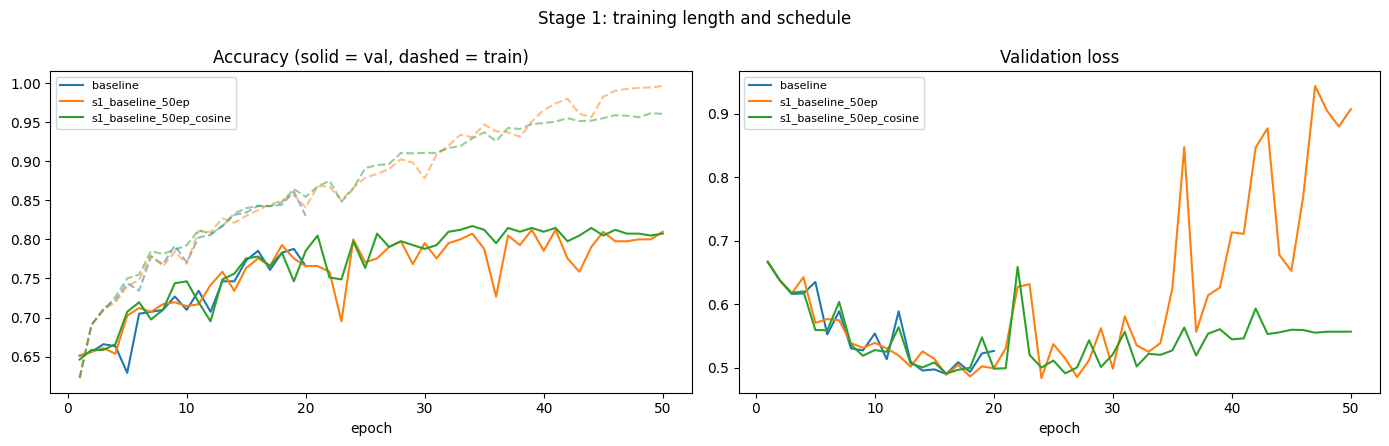


-> Using scheduler='cosine', epochs=50 from now on


In [ ]:
stage1 = [
    {**baseline_config, 'name': 's1_baseline_50ep',        'epochs': 50, 'scheduler': 'none'},
    {**baseline_config, 'name': 's1_baseline_50ep_cosine', 'epochs': 50, 'scheduler': 'cosine'},
]
for cfg in stage1:
    run_or_load(cfg)

df1 = load_results(['baseline', 's1_'])
display(df1[SHOW_COLS])
plot_curves(['baseline', 's1_baseline_50ep', 's1_baseline_50ep_cosine'], 'Stage 1: training length and schedule')

# Pick the schedule for later stages (override by hand if you disagree)
r = df1.set_index('name')['val_acc_last5']
SCHEDULER = 'cosine' if r['s1_baseline_50ep_cosine'] >= r['s1_baseline_50ep'] else 'none'
EPOCHS = 50
print(f'\n-> Using scheduler={SCHEDULER!r}, epochs={EPOCHS} from now on')

## 12. Stage 2 — optimizer × learning rate

Adam and SGD (momentum 0.9, Nesterov) have very different useful learning-rate ranges, so each gets its own
log-spaced grid. Comparing them at the same learning rate would be unfair to one of them.
Batch norm is still off here, so this is a clean optimizer comparison.

In [ ]:
LR_GRID = {
    'adam': [1e-4, 3e-4, 1e-3, 3e-3],
    'sgd':  [3e-3, 1e-2, 3e-2, 1e-1],
}
COMMON = {**baseline_config, 'epochs': EPOCHS, 'scheduler': SCHEDULER}

for opt, lrs in LR_GRID.items():
    for lr in lrs:
        run_or_load({**COMMON, 'name': f's2_{opt}_lr{lr:g}', 'optimizer': opt, 'lr': lr})

df2 = load_results(['s2_'])
display(df2[SHOW_COLS])

[loaded] s2_adam_lr0.0001               best val 0.7268
[loaded] s2_adam_lr0.0003               best val 0.7780
[loaded] s2_adam_lr0.001                best val 0.8024
[loaded] s2_adam_lr0.003                best val 0.7927
[loaded] s2_sgd_lr0.003                 best val 0.6805
[loaded] s2_sgd_lr0.01                  best val 0.7585
[loaded] s2_sgd_lr0.03                  best val 0.8073
[loaded] s2_sgd_lr0.1                   best val 0.8049


,name,optimizer,lr,batchnorm,scheduler,epochs,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s2_sgd_lr0.1,sgd,0.1000,False,cosine,50,0.8049,38,0.8015,0.9209,0.1194,5.5900
1,s2_adam_lr0.001,adam,0.0010,False,cosine,50,0.8024,35,0.7927,0.9476,0.1549,5.6839
2,s2_sgd_lr0.03,sgd,0.0300,False,cosine,50,0.8073,42,0.7917,0.8722,0.0805,5.6029
3,s2_adam_lr0.003,adam,0.0030,False,cosine,50,0.7927,37,0.7888,0.9251,0.1363,5.6370
4,s2_adam_lr0.0003,adam,0.0003,False,cosine,50,0.7780,49,0.7751,0.8440,0.0689,5.6384
5,s2_sgd_lr0.01,sgd,0.0100,False,cosine,50,0.7585,42,0.7546,0.8234,0.0687,5.5667
6,s2_adam_lr0.0001,adam,0.0001,False,cosine,50,0.7268,36,0.7161,0.7949,0.0788,5.6182
7,s2_sgd_lr0.003,sgd,0.0030,False,cosine,50,0.6805,44,0.6717,0.7384,0.0667,5.5558


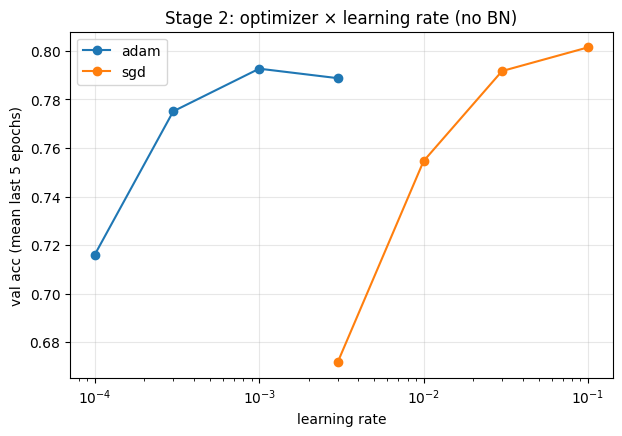

Best per optimizer: {'adam': 's2_adam_lr0.001', 'sgd': 's2_sgd_lr0.1'}


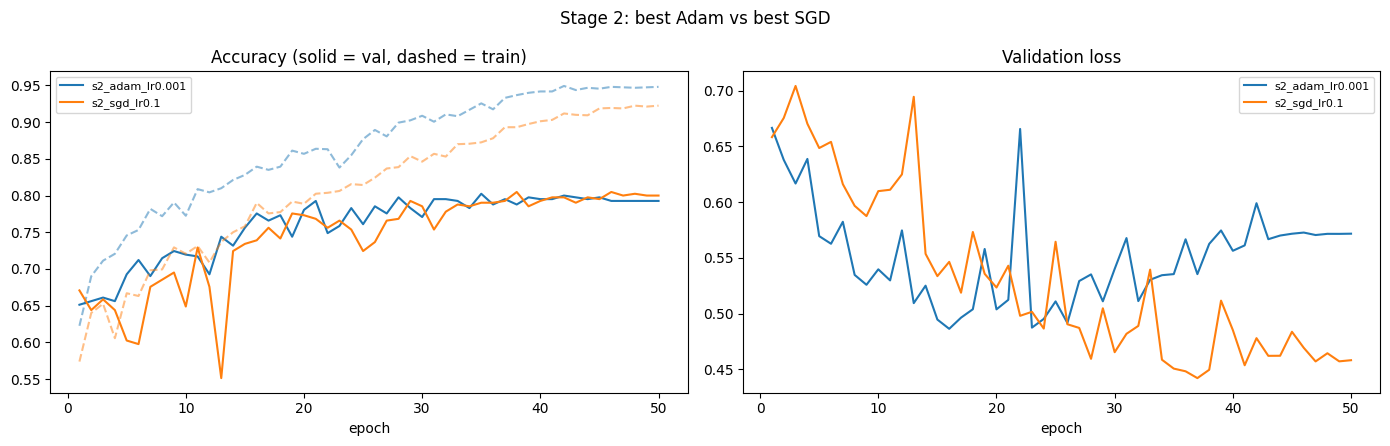

In [ ]:
def plot_lr_sweep(df, title, split_by_bn=False):
    """Validation accuracy (mean of last 5 epochs) vs learning rate, one line per optimizer (and BN setting)."""
    plt.figure(figsize=(7, 4.5))
    groups = ['optimizer', 'batchnorm'] if split_by_bn else ['optimizer']
    for key, g in df.groupby(groups):
        g = g.sort_values('lr')
        key = key if isinstance(key, tuple) else (key,)
        lab = key[0] + (' + BN' if split_by_bn and key[1] else '')
        plt.plot(g['lr'], g['val_acc_last5'], 'o-' if not (split_by_bn and key[1]) else 's--', label=lab)
    plt.xscale('log'); plt.xlabel('learning rate'); plt.ylabel('val acc (mean last 5 epochs)')
    plt.title(title); plt.grid(alpha=0.3); plt.legend(); plt.show()

plot_lr_sweep(df2, 'Stage 2: optimizer × learning rate (no BN)')

best2 = {opt: df2[df2.optimizer == opt].iloc[0]['name'] for opt in LR_GRID}
print('Best per optimizer:', best2)
plot_curves(list(best2.values()), 'Stage 2: best Adam vs best SGD')

## 13. Stage 3 — batch normalization

Every Stage 2 run is repeated with batch norm. BN usually tolerates larger learning rates, so each grid is
extended one step upwards. This answers both "does BN help?" and "does BN shift the best learning rate?".

If you are short on GPU time, set `STAGE3_OPTIMIZERS = [<winner of stage 2>]` to halve the number of runs.

[loaded] s3_adam_lr0.0001_bn            best val 0.8317
[loaded] s3_adam_lr0.0003_bn            best val 0.8341
[loaded] s3_adam_lr0.001_bn             best val 0.8537
[loaded] s3_adam_lr0.003_bn             best val 0.8537
[loaded] s3_adam_lr0.01_bn              best val 0.8610
[loaded] s3_sgd_lr0.003_bn              best val 0.8366
[loaded] s3_sgd_lr0.01_bn               best val 0.8439
[loaded] s3_sgd_lr0.03_bn               best val 0.8561
[loaded] s3_sgd_lr0.1_bn                best val 0.8585
[loaded] s3_sgd_lr0.3_bn                best val 0.8195


,name,optimizer,lr,batchnorm,scheduler,epochs,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s3_adam_lr0.01_bn,adam,0.0100,True,cosine,50,0.8610,43,0.8522,0.9651,0.1129,5.6148
1,s3_sgd_lr0.03_bn,sgd,0.0300,True,cosine,50,0.8561,47,0.8502,0.9984,0.1481,5.6043
2,s3_adam_lr0.003_bn,adam,0.0030,True,cosine,50,0.8537,47,0.8463,0.9822,0.1359,5.6639
3,s3_sgd_lr0.1_bn,sgd,0.1000,True,cosine,50,0.8585,40,0.8449,0.9594,0.1145,5.6513
4,s3_sgd_lr0.01_bn,sgd,0.0100,True,cosine,50,0.8439,46,0.8385,0.9979,0.1593,5.6066
5,s3_adam_lr0.001_bn,adam,0.0010,True,cosine,50,0.8537,45,0.8376,0.9949,0.1573,5.6280
6,s3_adam_lr0.0001_bn,adam,0.0001,True,cosine,50,0.8317,34,0.8283,0.9274,0.0991,5.5863
7,s3_adam_lr0.0003_bn,adam,0.0003,True,cosine,50,0.8341,44,0.8254,0.9844,0.1590,5.5918
8,s3_sgd_lr0.003_bn,sgd,0.0030,True,cosine,50,0.8366,34,0.8195,0.9734,0.1539,5.6217
9,s3_sgd_lr0.3_bn,sgd,0.3000,True,cosine,50,0.8195,49,0.8117,0.9096,0.0979,5.5813


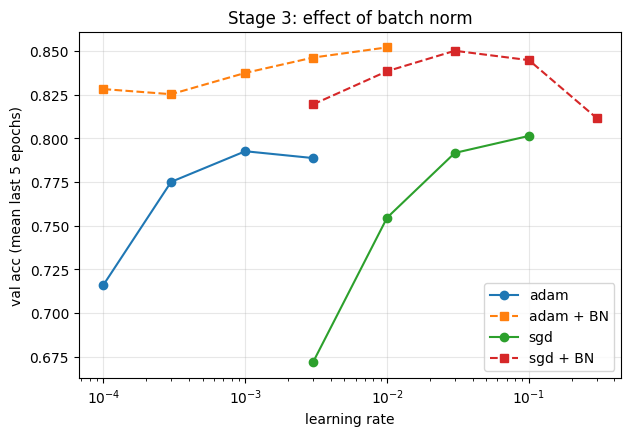

In [ ]:
STAGE3_OPTIMIZERS = ['adam', 'sgd']
LR_GRID_BN = {
    'adam': LR_GRID['adam'] + [1e-2],
    'sgd':  LR_GRID['sgd']  + [3e-1],
}

for opt in STAGE3_OPTIMIZERS:
    for lr in LR_GRID_BN[opt]:
        run_or_load({**COMMON, 'name': f's3_{opt}_lr{lr:g}_bn', 'optimizer': opt, 'lr': lr,
                     'use_batchnorm': True})

df3 = load_results(['s2_', 's3_'])
display(df3[SHOW_COLS])
plot_lr_sweep(df3, 'Stage 3: effect of batch norm', split_by_bn=True)

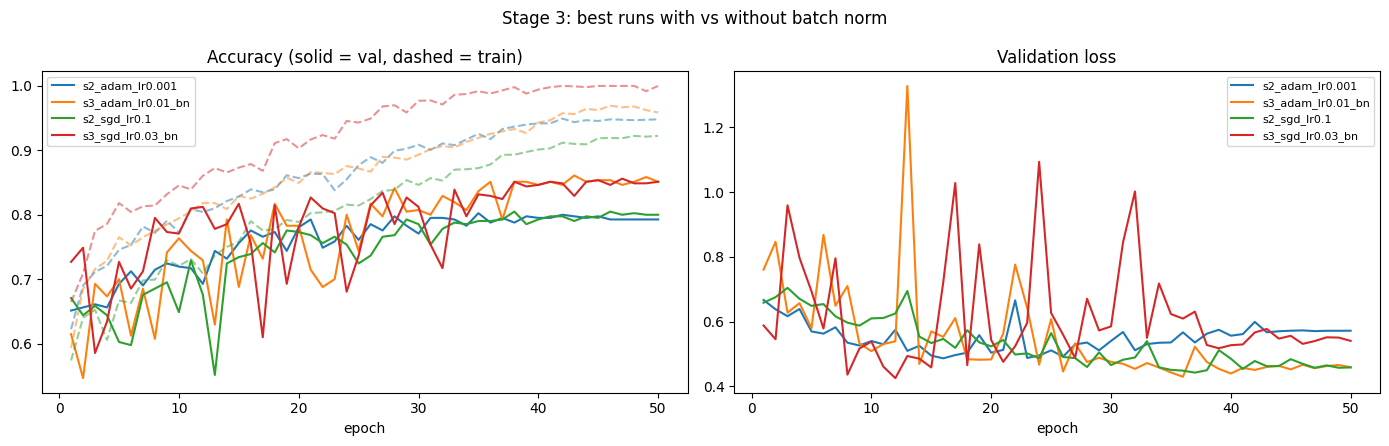

In [ ]:
# Best run with and without BN for each optimizer: compare stability and speed of convergence
compare = []
for opt in STAGE3_OPTIMIZERS:
    for bn in [False, True]:
        sub = df3[(df3.optimizer == opt) & (df3.batchnorm == bn)]
        if len(sub):
            compare.append(sub.iloc[0]['name'])
plot_curves(compare, 'Stage 3: best runs with vs without batch norm')

## 14. Summary so far

All runs ranked by `val_acc_last5`. The best configuration is saved to `best_config_stage3.json` so the next
stages (capacity, augmentation, regularization) can start from it, possibly in a fresh Colab session.

In [ ]:
df_all = load_results()
display(df_all[SHOW_COLS].head(15))

best_name = df_all.iloc[0]['name']
best_config = load_summary(best_name)['config']
with open(os.path.join(RESULTS_DIR, 'best_config_stage3.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

print(f'\nBest run: {best_name}')
print(f"  val acc last5: {df_all.iloc[0]['val_acc_last5']:.4f} | best val acc: {df_all.iloc[0]['best_val_acc']:.4f}")
print(f"  train/val gap: {df_all.iloc[0]['gap']:.4f}  (large gap -> regularize/augment next; small gap -> add capacity)")
print(f'  improvement over baseline (val last5): '
      f"{df_all.iloc[0]['val_acc_last5'] - df_all.set_index('name').loc['baseline', 'val_acc_last5']:+.4f}")
print(f'  total GPU time so far: {df_all.time_min.sum():.0f} min')

,name,optimizer,lr,batchnorm,scheduler,epochs,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s3_adam_lr0.01_bn,adam,0.0100,True,cosine,50,0.8610,43,0.8522,0.9651,0.1129,5.6148
1,s3_sgd_lr0.03_bn,sgd,0.0300,True,cosine,50,0.8561,47,0.8502,0.9984,0.1481,5.6043
2,s3_adam_lr0.003_bn,adam,0.0030,True,cosine,50,0.8537,47,0.8463,0.9822,0.1359,5.6639
3,s3_sgd_lr0.1_bn,sgd,0.1000,True,cosine,50,0.8585,40,0.8449,0.9594,0.1145,5.6513
4,s3_sgd_lr0.01_bn,sgd,0.0100,True,cosine,50,0.8439,46,0.8385,0.9979,0.1593,5.6066
5,s3_adam_lr0.001_bn,adam,0.0010,True,cosine,50,0.8537,45,0.8376,0.9949,0.1573,5.6280
6,s3_adam_lr0.0001_bn,adam,0.0001,True,cosine,50,0.8317,34,0.8283,0.9274,0.0991,5.5863
7,s3_adam_lr0.0003_bn,adam,0.0003,True,cosine,50,0.8341,44,0.8254,0.9844,0.1590,5.5918
8,s3_sgd_lr0.003_bn,sgd,0.0030,True,cosine,50,0.8366,34,0.8195,0.9734,0.1539,5.6217
9,s3_sgd_lr0.3_bn,sgd,0.3000,True,cosine,50,0.8195,49,0.8117,0.9096,0.0979,5.5813



Best run: s3_adam_lr0.01_bn
  val acc last5: 0.8522 | best val acc: 0.8610
  train/val gap: 0.1129  (large gap -> regularize/augment next; small gap -> add capacity)
  improvement over baseline (val last5): +0.0756
  total GPU time so far: 114 min


**Loading a saved model later** (e.g. for test evaluation or saliency maps):

```python
cfg = load_summary(best_name)['config']
model = build_model(cfg).to(device)
model.load_state_dict(torch.load(os.path.join(RESULTS_DIR, f'{best_name}.pt'), map_location=device))
```

# Stage 4 — Fighting overfitting

After Stages 1–3 the best models reach 96–99% train accuracy but only ~85% validation accuracy, so the next
lever is regularization rather than the learning rate:

| Sub-stage | Question | Runs |
|---|---|---|
| 4a | Does data augmentation help, and how much? (`none` / `basic` / `strong`) | 3 |
| 4b | Do dropout and weight decay help on top of the best augmentation? | 4 |
| 4c | Only if the gap has closed: does more capacity help? | 0–2 |

**Noise level.** In Stages 1–3 two runs with identical configuration and seed (`s1_baseline_50ep_cosine` and
`s2_adam_lr0.001`) differed by 1.5 points because of non-deterministic GPU operations. Differences smaller
than `NOISE` below should be treated as ties, and when there is a tie the simpler option is preferred.

**Epochs.** Augmented data takes longer to fit, so all Stage 4 runs use 80 epochs, including a new
no-augmentation reference so the comparison is fair.

## 15. Stage 4 setup

In [ ]:
NOISE = 0.015          # run-to-run spread observed in stages 1-3
STAGE4_EPOCHS = 80

# Starting point. Adam lr=1e-2 was the top of the tested grid, and Adam lr=3e-3 is within noise of it,
# so the more central 3e-3 is used. Change to 's3_adam_lr0.01_bn' to start from the nominal winner instead.
STAGE4_BASE = 's3_adam_lr0.003_bn'

base4 = {**load_summary(STAGE4_BASE)['config'], 'epochs': STAGE4_EPOCHS}
base4['channels'] = tuple(base4['channels'])
print('Stage 4 base config:')
for k, v in base4.items():
    print(f'  {k:16s} {v}')

SHOW_COLS4 = ['name', 'augmentation', 'dropout', 'optimizer', 'weight_decay', 'channels', 'convs/block',
              'best_val_acc', 'best_epoch', 'val_acc_last5', 'train_acc_last5', 'gap', 'time_min']


def result_row(name):
    """Exact-name lookup (load_results matches by prefix)."""
    df = load_results([name])
    return df[df.name == name].iloc[0]


def pick_best(df, simplicity_order):
    """Best run by val_acc_last5, but prefer an earlier (simpler) entry of `simplicity_order`
    if it is within NOISE of the top score."""
    scores = df.set_index('name')['val_acc_last5']
    top = scores.max()
    for name in simplicity_order:
        if name in scores and scores[name] >= top - NOISE:
            return name
    return scores.idxmax()

Stage 4 base config:
  name             s3_adam_lr0.003_bn
  seed             42
  img_size         128
  batch_size       64
  augmentation     none
  channels         (32, 64, 128, 256)
  convs_per_block  1
  use_batchnorm    True
  dropout          0.0
  optimizer        adam
  lr               0.003
  weight_decay     0.0
  scheduler        cosine
  epochs           80


## 16. Stage 4a — data augmentation

- `none`: resize only (the reference, retrained for 80 epochs).
- `basic`: horizontal flip and ±15° rotation. Geometric changes only.
- `strong`: random resized crop (60–100% of the image), flip, ±20° rotation and colour jitter.
  Colour jitter directly tests the hypothesis from the baseline error analysis that the network relies on
  reddish-orange colour to recognise hotdogs.

[done]   s4a_aug_none                   best val 0.8585 | last5 0.8522 | train last5 0.9998 | 9.0 min
[done]   s4a_aug_basic                  best val 0.8537 | last5 0.8400 | train last5 0.9639 | 8.9 min
[done]   s4a_aug_strong                 best val 0.8244 | last5 0.8132 | train last5 0.8787 | 12.7 min


,name,augmentation,dropout,optimizer,weight_decay,channels,convs/block,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s4a_aug_none,none,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8585,60,0.8522,0.9998,0.1476,8.9541
1,s4a_aug_basic,basic,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8537,68,0.8400,0.9639,0.1239,8.9355
2,s4a_aug_strong,strong,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8244,49,0.8132,0.8787,0.0656,12.6587


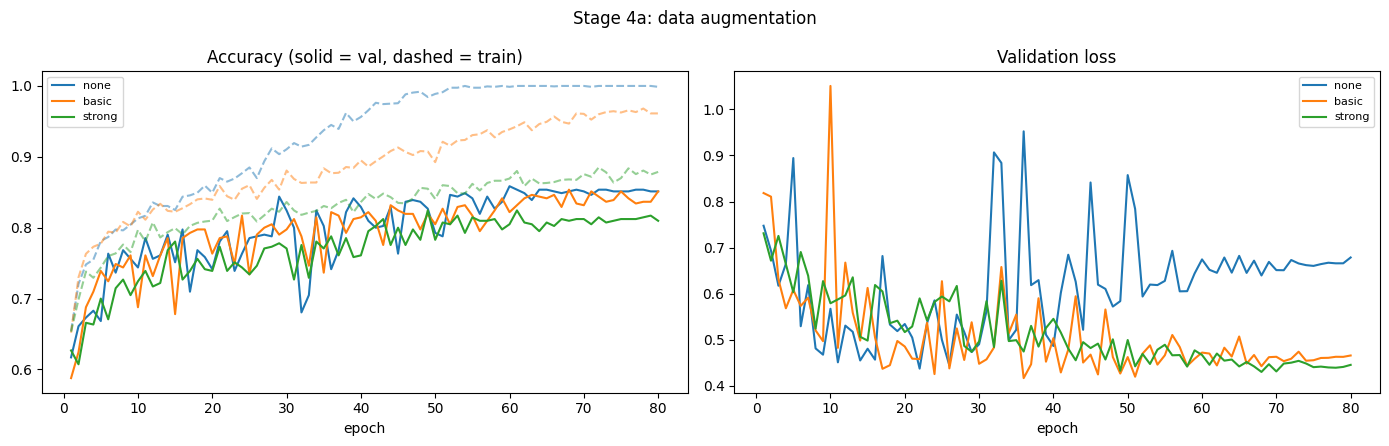

-> Best augmentation: 'none' (s4a_aug_none)


In [ ]:
AUG_LEVELS = ['none', 'basic', 'strong']
for aug in AUG_LEVELS:
    run_or_load({**base4, 'name': f's4a_aug_{aug}', 'augmentation': aug})

df4a = load_results(['s4a_'])
display(df4a[SHOW_COLS4])
plot_curves([f's4a_aug_{a}' for a in AUG_LEVELS], 'Stage 4a: data augmentation', labels=AUG_LEVELS)

best4a = pick_best(df4a, [f's4a_aug_{a}' for a in AUG_LEVELS])
BEST_AUG = load_summary(best4a)['config']['augmentation']
print(f'-> Best augmentation: {BEST_AUG!r} ({best4a})')

## 17. Stage 4b — dropout and weight decay

All runs use the best augmentation from 4a.

- **Dropout** 0.3 and 0.5 before the final linear layer.
- **Weight decay** with AdamW. AdamW applies decay separately from the gradient step (the decay per step is
  `lr × weight_decay`), so it needs much larger values than weight decay inside plain Adam or SGD.
  `0.05` is a typical setting.
- **Combined**: the better dropout value together with weight decay, run automatically after the first three.

[done]   s4b_none_do0.3                 best val 0.8561 | last5 0.8498 | train last5 0.9996 | 8.5 min
[done]   s4b_none_do0.5                 best val 0.8683 | last5 0.8576 | train last5 0.9970 | 8.6 min
[done]   s4b_none_wd0.05                best val 0.8659 | last5 0.8571 | train last5 1.0000 | 8.6 min
[done]   s4b_none_do0.5_wd0.05          best val 0.8634 | last5 0.8585 | train last5 0.9985 | 8.7 min


,name,augmentation,dropout,optimizer,weight_decay,channels,convs/block,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s4b_none_do0.5_wd0.05,none,0.5,adamw,0.05,"(32, 64, 128, 256)",1,0.8634,59,0.8585,0.9985,0.1400,8.6748
1,s4b_none_do0.5,none,0.5,adam,0.00,"(32, 64, 128, 256)",1,0.8683,55,0.8576,0.9970,0.1394,8.6404
2,s4b_none_wd0.05,none,0.0,adamw,0.05,"(32, 64, 128, 256)",1,0.8659,65,0.8571,1.0000,0.1429,8.6265
3,s4a_aug_none,none,0.0,adam,0.00,"(32, 64, 128, 256)",1,0.8585,60,0.8522,0.9998,0.1476,8.9541
4,s4b_none_do0.3,none,0.3,adam,0.00,"(32, 64, 128, 256)",1,0.8561,57,0.8498,0.9996,0.1499,8.5405


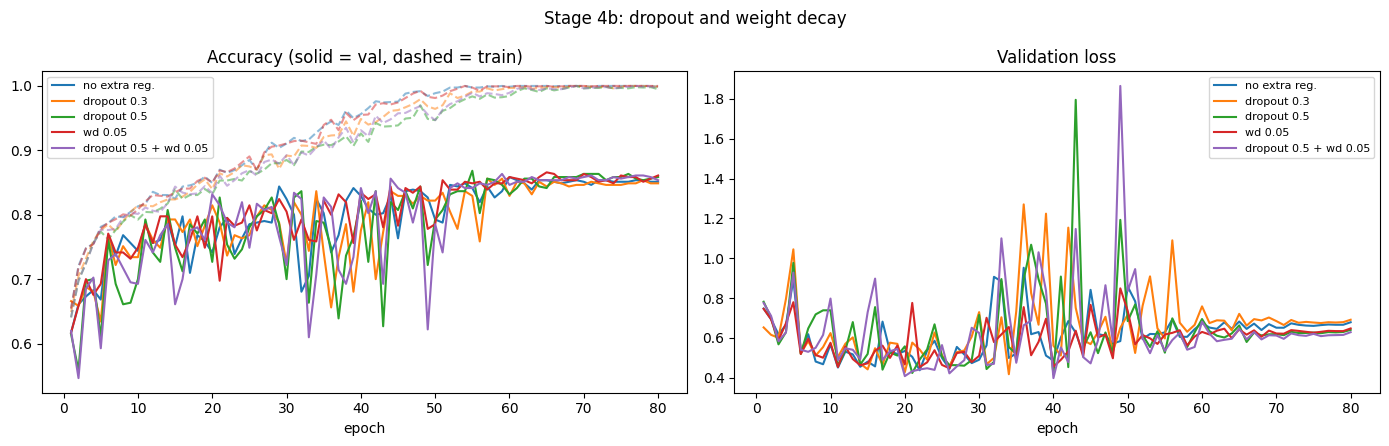

-> Best after 4b: s4a_aug_none


In [ ]:
base4b = {**base4, 'augmentation': BEST_AUG}
ref4b = best4a   # the 4a winner is the "no extra regularization" reference

for p in [0.3, 0.5]:
    run_or_load({**base4b, 'name': f's4b_{BEST_AUG}_do{p}', 'dropout': p})
WD = 0.05
run_or_load({**base4b, 'name': f's4b_{BEST_AUG}_wd{WD}', 'optimizer': 'adamw', 'weight_decay': WD})

# Combine the better dropout value with weight decay
_d = load_results([f's4b_{BEST_AUG}_do']).set_index('name')['val_acc_last5']
best_p = 0.3 if _d[f's4b_{BEST_AUG}_do0.3'] >= _d[f's4b_{BEST_AUG}_do0.5'] else 0.5
run_or_load({**base4b, 'name': f's4b_{BEST_AUG}_do{best_p}_wd{WD}', 'dropout': best_p,
             'optimizer': 'adamw', 'weight_decay': WD})

names4b = [ref4b, f's4b_{BEST_AUG}_do0.3', f's4b_{BEST_AUG}_do0.5', f's4b_{BEST_AUG}_wd{WD}',
           f's4b_{BEST_AUG}_do{best_p}_wd{WD}']
df4b = load_results(names4b)
df4b = df4b[df4b.name.isin(names4b)]
display(df4b[SHOW_COLS4])
plot_curves(names4b, 'Stage 4b: dropout and weight decay',
            labels=['no extra reg.', 'dropout 0.3', 'dropout 0.5', f'wd {WD}', f'dropout {best_p} + wd {WD}'])

best4b = pick_best(df4b, names4b)   # simplicity order: reference first, combination last
print(f'-> Best after 4b: {best4b}')

## 18. Stage 4c — capacity (conditional)

Only worth it if regularization has closed most of the train–val gap. A bigger network on a model that still
overfits heavily just overfits faster. Two variants are tried: doubled width, and two convolutions per block
(more depth and a larger receptive field at the same width). Set `FORCE_4C = True` to run them regardless.

In [ ]:
FORCE_4C = False
GAP_THRESHOLD = 0.06

best4b_row = result_row(best4b)
print(f"Gap of {best4b}: {best4b_row['gap']:.3f} (threshold {GAP_THRESHOLD})")

base4c = {**load_summary(best4b)['config']}
base4c['channels'] = tuple(base4c['channels'])
names4c = [best4b]

if best4b_row['gap'] < GAP_THRESHOLD or FORCE_4C:
    run_or_load({**base4c, 'name': 's4c_wide',  'channels': (64, 128, 256, 512)})
    run_or_load({**base4c, 'name': 's4c_2conv', 'convs_per_block': 2})
    names4c += ['s4c_wide', 's4c_2conv']
    df4c = load_results(names4c)
    df4c = df4c[df4c.name.isin(names4c)]
    display(df4c[SHOW_COLS4])
    plot_curves(names4c, 'Stage 4c: capacity', labels=['current', 'wide (64-512)', '2 convs / block'])
    best4 = pick_best(df4c, names4c)
else:
    print('-> Still overfitting clearly; skipping the capacity runs.')
    best4 = best4b

Gap of s4a_aug_none: 0.148 (threshold 0.06)
-> Still overfitting clearly; skipping the capacity runs.


## 19. Stage 4 summary

The best configuration is saved to `best_config_stage4.json`. It is the configuration to retrain with several
seeds and then evaluate once on the test set.

In [ ]:
df_s4 = load_results(['s3_', 's4'])
display(df_s4[SHOW_COLS4].head(12))

best_config = load_summary(best4)['config']
with open(os.path.join(RESULTS_DIR, 'best_config_stage4.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

r = result_row(best4)
ref = result_row(STAGE4_BASE)
print(f'\nBest Stage 4 run: {best4}')
for k in ['augmentation', 'dropout', 'optimizer', 'lr', 'weight_decay', 'channels', 'convs_per_block', 'epochs']:
    print(f'  {k:16s} {best_config[k]}')
print(f"  val acc last5: {r['val_acc_last5']:.4f}  (Stage 3 start: {ref['val_acc_last5']:.4f}, "
      f"change {r['val_acc_last5'] - ref['val_acc_last5']:+.4f})")
print(f"  train/val gap: {r['gap']:.4f}  (Stage 3 start: {ref['gap']:.4f})")
print(f'  Stage 4 GPU time: {df_s4[df_s4.name.str.startswith("s4")].time_min.sum():.0f} min')

,name,augmentation,dropout,optimizer,weight_decay,channels,convs/block,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s4b_none_do0.5_wd0.05,none,0.5,adamw,0.05,"(32, 64, 128, 256)",1,0.8634,59,0.8585,0.9985,0.1400,8.6748
1,s4b_none_do0.5,none,0.5,adam,0.00,"(32, 64, 128, 256)",1,0.8683,55,0.8576,0.9970,0.1394,8.6404
2,s4b_none_wd0.05,none,0.0,adamw,0.05,"(32, 64, 128, 256)",1,0.8659,65,0.8571,1.0000,0.1429,8.6265
3,s4a_aug_none,none,0.0,adam,0.00,"(32, 64, 128, 256)",1,0.8585,60,0.8522,0.9998,0.1476,8.9541
4,s3_adam_lr0.01_bn,none,0.0,adam,0.00,"(32, 64, 128, 256)",1,0.8610,43,0.8522,0.9651,0.1129,5.6148
5,s3_sgd_lr0.03_bn,none,0.0,sgd,0.00,"(32, 64, 128, 256)",1,0.8561,47,0.8502,0.9984,0.1481,5.6043
6,s4b_none_do0.3,none,0.3,adam,0.00,"(32, 64, 128, 256)",1,0.8561,57,0.8498,0.9996,0.1499,8.5405
7,s3_adam_lr0.003_bn,none,0.0,adam,0.00,"(32, 64, 128, 256)",1,0.8537,47,0.8463,0.9822,0.1359,5.6639
8,s3_sgd_lr0.1_bn,none,0.0,sgd,0.00,"(32, 64, 128, 256)",1,0.8585,40,0.8449,0.9594,0.1145,5.6513
9,s4a_aug_basic,basic,0.0,adam,0.00,"(32, 64, 128, 256)",1,0.8537,68,0.8400,0.9639,0.1239,8.9355



Best Stage 4 run: s4a_aug_none
  augmentation     none
  dropout          0.0
  optimizer        adam
  lr               0.003
  weight_decay     0.0
  channels         [32, 64, 128, 256]
  convs_per_block  1
  epochs           80
  val acc last5: 0.8522  (Stage 3 start: 0.8463, change +0.0059)
  train/val gap: 0.1476  (Stage 3 start: 0.1359)
  Stage 4 GPU time: 65 min


## 20. Strong augmentation without random cropping, 200 epochs

Stage 4a suggested that `strong` augmentation was *undertrained* rather than harmful: it was the only setting
that closed the train/val gap (14.8 → 6.6 points), but training accuracy was still only 87.9% and rising at
epoch 80.

Two changes here:

- **`strong_nocrop`**: the same as `strong` but with `RandomResizedCrop` replaced by a plain resize. The random
  crop (scale 0.6–1.0) can cut the hotdog out of the frame while keeping the `hotdog` label, which injects label
  noise. What remains is flip, ±20° rotation and colour jitter — the colour jitter being the part that tests the
  "the network keys on reddish-orange colour" hypothesis.
- **200 epochs** instead of 80, so the harder training distribution has time to be fitted.

`get_transforms` is redefined here rather than edited in section 3, so the earlier results stay reproducible.

## 20. Strong augmentation without random cropping, 200 epochs

Stage 4a suggested that `strong` augmentation was *undertrained* rather than harmful: it was the only setting
that closed the train/val gap (14.8 → 6.6 points), but training accuracy was still only 87.9% and rising at
epoch 80.

Two changes here:

- **`strong_nocrop`**: the same as `strong` but with `RandomResizedCrop` replaced by a plain resize. The random
  crop (scale 0.6–1.0) can cut the hotdog out of the frame while keeping the `hotdog` label, which injects label
  noise. What remains is flip, ±20° rotation and colour jitter — the colour jitter being the part that tests the
  "the network keys on reddish-orange colour" hypothesis.
- **200 epochs** instead of 80, so the harder training distribution has time to be fitted.

`get_transforms` is redefined here rather than edited in section 3, so the earlier results stay reproducible.

In [ ]:
_get_transforms_orig = get_transforms

def get_transforms(img_size=128, augmentation='none'):
    if augmentation != 'strong_nocrop':
        return _get_transforms_orig(img_size, augmentation)
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    eval_tf = transforms.Compose([transforms.Resize((img_size, img_size)),
                                  transforms.ToTensor(), normalize])
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),     # no RandomResizedCrop
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(0.3, 0.3, 0.3, 0.05),
        transforms.ToTensor(), normalize])
    return train_tf, eval_tf

# Sanity check: the transform pipeline actually in use
print(get_transforms(128, 'strong_nocrop')[0])

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


[done]   s4d_strongnocrop_200ep         best val 0.8610 | last5 0.8566 | train last5 0.9601 | 31.3 min


,name,augmentation,dropout,optimizer,weight_decay,channels,convs/block,best_val_acc,best_epoch,val_acc_last5,train_acc_last5,gap,time_min
0,s4d_strongnocrop_200ep,strong_nocrop,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8610,164,0.8566,0.9601,0.1035,31.2653
1,s4a_aug_none,none,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8585,60,0.8522,0.9998,0.1476,8.9541
2,s4a_aug_strong,strong,0.0,adam,0.0,"(32, 64, 128, 256)",1,0.8244,49,0.8132,0.8787,0.0656,12.6587


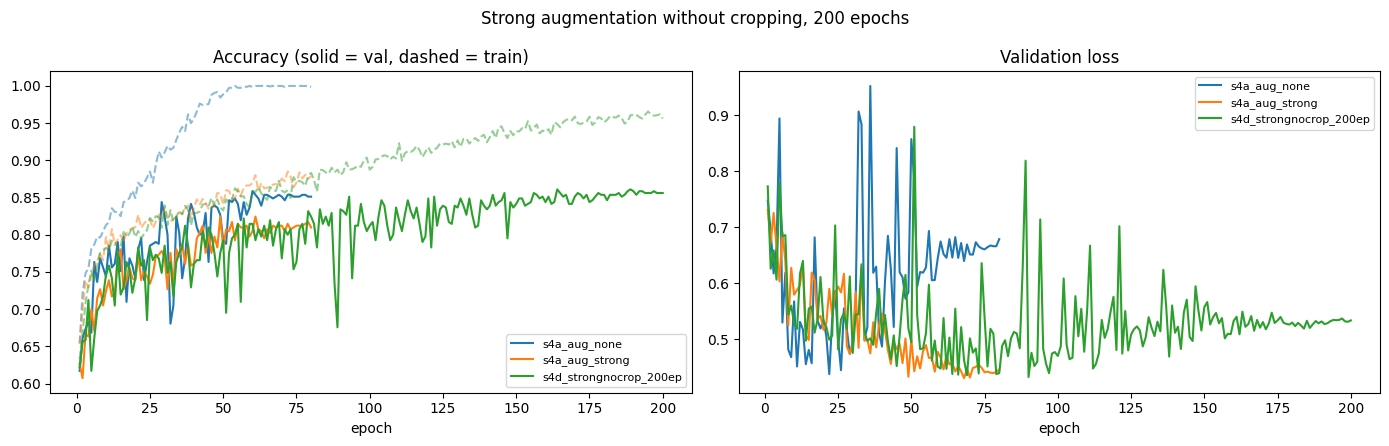

strong_nocrop @200ep : val 0.8566 | train 0.9601 | gap 0.1035
strong        @80ep  : val 0.8132 | train 0.8787 | gap 0.0656
none          @80ep  : val 0.8522 | train 0.9998 | gap 0.1476

vs. no augmentation: +0.0044 (noise level ~0.015)


In [ ]:
LONG_EPOCHS = 200

# Optional: a no-augmentation reference at the same 200 epochs, so the comparison is not
# confounded by training length. Adds ~22 min. Set to True if you want the clean comparison.
RUN_LONG_REFERENCE = False

run_or_load({**base4, 'name': 's4d_strongnocrop_200ep',
             'augmentation': 'strong_nocrop', 'epochs': LONG_EPOCHS})

names20 = ['s4a_aug_none', 's4a_aug_strong', 's4d_strongnocrop_200ep']
if RUN_LONG_REFERENCE:
    run_or_load({**base4, 'name': 's4d_none_200ep', 'augmentation': 'none', 'epochs': LONG_EPOCHS})
    names20.insert(1, 's4d_none_200ep')

df20 = load_results(names20)
df20 = df20[df20.name.isin(names20)]
display(df20[SHOW_COLS4])
plot_curves(names20, 'Strong augmentation without cropping, 200 epochs')

r20 = result_row('s4d_strongnocrop_200ep')
r_none = result_row('s4a_aug_none')
r_strong = result_row('s4a_aug_strong')
print(f"strong_nocrop @200ep : val {r20['val_acc_last5']:.4f} | train {r20['train_acc_last5']:.4f} | gap {r20['gap']:.4f}")
print(f"strong        @80ep  : val {r_strong['val_acc_last5']:.4f} | train {r_strong['train_acc_last5']:.4f} | gap {r_strong['gap']:.4f}")
print(f"none          @80ep  : val {r_none['val_acc_last5']:.4f} | train {r_none['train_acc_last5']:.4f} | gap {r_none['gap']:.4f}")
print(f"\nvs. no augmentation: {r20['val_acc_last5'] - r_none['val_acc_last5']:+.4f} "
      f"(noise level ~{NOISE:.3f})")